
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E01_gradient_descent.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Gradient descent exercises

---
These are introductory exercises in Machine learning with focus in **gradient descent** .

<p class = "alert alert-info" role="alert"><b>Note</b> all datasets used in this exercise can be found under Data folder of the course Github repo</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Simulate dataset (*)

Simulate datasets according to these rules:

- set random seed to 42
- (1000,2) samples from $X \sim \mathcal{U}(0,1)$ , i.e. 1000 rows, 2 columns. 
- 1000 samples from $\epsilon \sim \mathcal{N}(0,1)$
- $y = 3x_1 + 5x_2 + 3 + \epsilon$ , where $x_i$ is column $i$ of $X$

Finally add a column of ones for the intercept to $X$.

<details>

<summary>Hint</summary>

Use for simulating X

´´´
np.random.rand(samples, 2)
´´´

to concatenate with ones, use ```np.c_[..., ...]```

</details>

<details>

<summary>Answer</summary>

```
array([[1.        , 0.37454012, 0.95071431],
       [1.        , 0.73199394, 0.59865848],
       [1.        , 0.15601864, 0.15599452],
       [1.        , 0.05808361, 0.86617615],
       [1.        , 0.60111501, 0.70807258]])

```

</details>

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
rng = np.random.default_rng()
X = np.random.rand(1000, 2)
epsilon = np.random.normal(0, 1, 1000) #Genererar brus 
y = 3*X[:,0] + 5*X[:,1] + 3 + epsilon

X = np.c_[np.ones(1000), X]

## 1. Gradient descent - learning rate (*)

Use gradient descent to calculate $\vec{\theta} = (\theta_0, \theta_1, \theta_2)^T$ 

&nbsp; a) Use $\eta = 0.1$ and calculate $\vec{\theta}$ for each fifth epoch from 1 to 500. So the procedure is as follows:
- calculate $\vec{\theta}$ for epochs = 1
- calculate $\vec{\theta}$ for epochs = 6
- ...
- calculate $\vec{\theta}$ for epochs = 496

Plot these $\vec{\theta}$ values against epochs. (*)

&nbsp; b) Do the same as for a) but with learning rate $\eta = 0.01$, 5000 epochs and for each 20th epoch. What do you notice when changing the learning rate? (*)

&nbsp; c) Experiment with larger and smaller $\eta$ and see what happens.

<details>

<summary>Answer</summary>

a) 

<img src="../assets/grad_desc_converg.png" height="200"/>

b) 

<img src="../assets/grad_desc_converg_001.png" height="200"/>

</details>

---

## A)

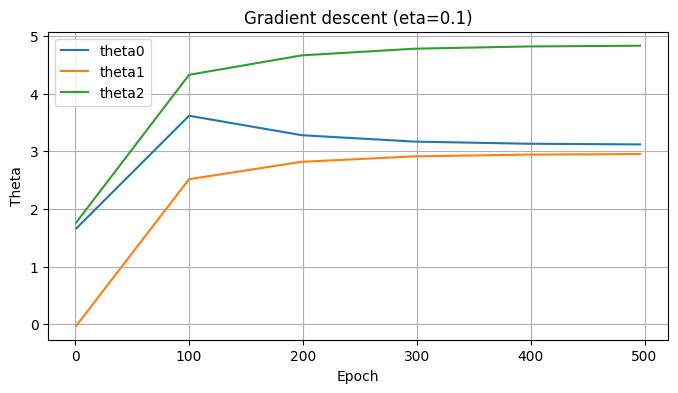

Sista theta efter 500 epoker: [3.12060544 2.95398773 4.83305597]
[[ 1.66486266 -0.0238544   1.7686394 ]
 [ 3.61843225  2.51784342  4.32792215]
 [ 3.28069044  2.81895865  4.66557272]
 [ 3.16956614  2.91355496  4.78099633]
 [ 3.13294518  2.94391201  4.81982428]
 [ 3.12086604  2.95377615  4.83277535]]


In [5]:
eta = 0.1
epochs = 500

theta = rng.standard_normal(3)

theta_history = []
epoch_history = []

n = X.shape[0]

for epoch in range(1, epochs + 1):

    y_pred = X @ theta
    grad = (2/n) * X.T @ (y_pred - y) 

    theta = theta - eta * grad

    if epoch in range(1, 500, 99):
        epoch_history.append(epoch)
        theta_history.append(theta.copy())
        

theta_history = np.array(theta_history)

plt.figure(figsize=(8, 4))
plt.plot(epoch_history, theta_history[:, 0], label="theta0")
plt.plot(epoch_history, theta_history[:, 1], label="theta1")
plt.plot(epoch_history, theta_history[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta")
plt.title("Gradient descent (eta=0.1)")
plt.grid(True)
plt.legend()
plt.show()


print("Sista theta efter 500 epoker:", theta)
print(theta_history)

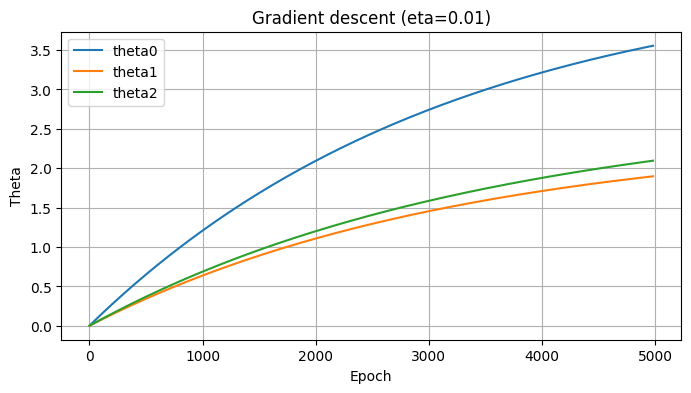

Sista theta efter 5000 epoker: [3.12102794 2.95382282 4.8324288 ]


In [36]:
eta = 0.0001
epochs = 500000

theta = np.zeros(X.shape[1])

theta_history = []
epoch_history = []

n = X.shape[0]

for epoch in range(1, epochs + 1):

    y_pred = X @ theta
    grad = (2/n) * X.T @ (y_pred - y) 

    theta = theta - eta * grad

    if epoch in range(1, 5000, 20):
        epoch_history.append(epoch)
        theta_history.append(theta.copy())
        

theta_history = np.array(theta_history)

plt.figure(figsize=(8, 4))
plt.plot(epoch_history, theta_history[:, 0], label="theta0")
plt.plot(epoch_history, theta_history[:, 1], label="theta1")
plt.plot(epoch_history, theta_history[:, 2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta")
plt.title("Gradient descent (eta=0.01)")
plt.grid(True)
plt.legend()
plt.show()

print("Sista theta efter 5000 epoker:", theta)


## 2. Stochastic Gradient Descent - learning rate (**)

Repeat task 1 but using stochastic gradient descent instead. Also adjust number of epochs to see if you can find convergence. What kind of conclusions can you draw from your experiments. (**)

---

In [37]:
def mse(X, y, theta):
    err = X @ theta - y
    return np.mean(err**2)

def stochastic_gradient_descent(X, y, eta=0.01, epochs=100, log_every=1, seed=42):
    
    n, p = X.shape
    theta = np.zeros(p)
    rng = np.random.default_rng(seed)

    theta_history = []
    epoch_history = []
    mse_history = []

    for epoch in range(1, epochs + 1):
        idx = rng.permutation(n)
        X_shuf, y_shuf = X[idx], y[idx]

        for i in range(n):
            xi = X_shuf[i]
            yi = y_shuf[i]
            grad_i = 2 * xi * (xi @ theta - yi)
            theta -= eta * grad_i

        if (epoch -1) % log_every == 0:
            epoch_history.append(epoch)
            theta_history.append(theta.copy())
            mse_history.append(mse(X, y, theta))
    
    return np.array(epoch_history), np.array(theta_history), np.array(mse_history), theta

In [38]:
epochs_sgd, thetas_sgd, mse_sgd, theta_final_sgd = stochastic_gradient_descent(X, y, eta=0.01, epochs=1000, log_every=5)

print('Final theta (SGD):', theta_final_sgd)

Final theta (SGD): [3.03902081 2.96100418 4.83301263]


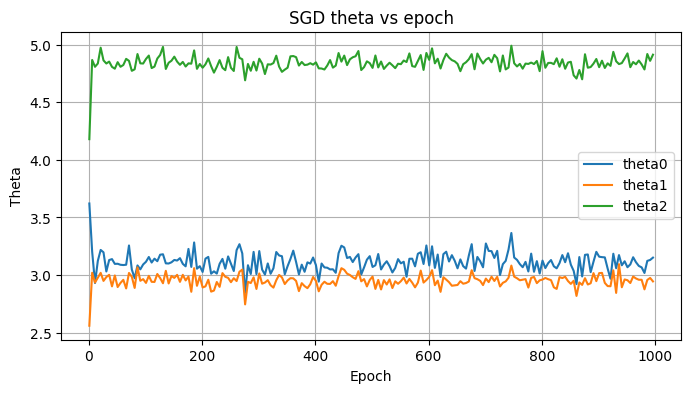

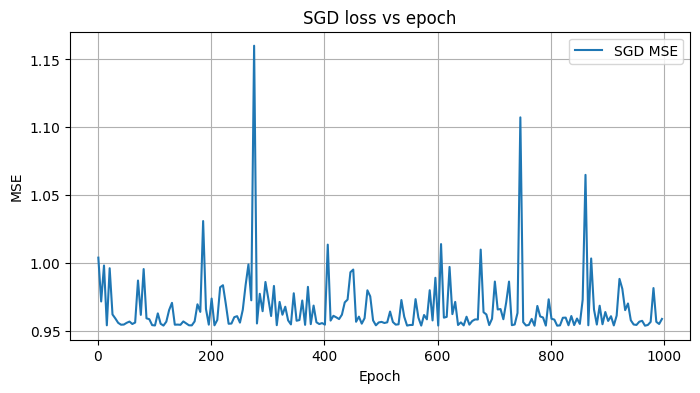

In [39]:
plt.figure(figsize=(8,4))
plt.plot(epochs_sgd, thetas_sgd[:,0], label="theta0")
plt.plot(epochs_sgd, thetas_sgd[:,1], label="theta1")
plt.plot(epochs_sgd, thetas_sgd[:,2], label="theta2")
plt.xlabel("Epoch")
plt.ylabel("Theta")
plt.title("SGD theta vs epoch")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(epochs_sgd, mse_sgd, label="SGD MSE")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("SGD loss vs epoch")
plt.grid(True)
plt.legend()
plt.show()


## 3. Mini Batch Gradient Descent (**)

Now try different sizes of mini-batches and make some exploratory plots to see convergence. Also you can make comparison to the other algorithms by using same $\eta$ and same amount of epochs to see how they differ from each other in terms of convergence. (**)

In [ ]:
batch1 = np.random

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---